In [30]:
import matplotlib
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve

import matplotlib.pyplot as plt
import numpy as np
np.random.seed(16)

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
filename = '/content/drive/MyDrive/MyLecture/2025/DB응용/제10주차_이진분류/diabetes.csv'
df = pd.read_csv(filename)
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [33]:
# 상위 5개 데이터를 출력한다
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [34]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing

In [36]:
df['Glucose'] = df['Glucose'].replace(0, np.nan)
df['BloodPressure'] = df['BloodPressure'].replace(0, np.nan)
df['SkinThickness'] = df['SkinThickness'].replace(0, np.nan)
df['Insulin'] = df['Insulin'].replace(0, np.nan)
df['BMI'] = df['BMI'].replace(0, np.nan)

In [37]:
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].mean())
df['BloodPressure'] = df['BloodPressure'].fillna(df['BloodPressure'].mean())
df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].mean())
df['Insulin'] = df['Insulin'].fillna(df['Insulin'].mean())
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())

In [38]:
# 데이터를 훈련 데이터셋과 테스트 데이터셋으로 분할

X = df.loc[:, df.columns != 'Outcome']
y = df.loc[:, 'Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 5)

In [39]:
X_train.shape

(614, 8)

In [40]:
print(X_train)

     Pregnancies  Glucose  BloodPressure  SkinThickness     Insulin   BMI  \
140            3    128.0           78.0       29.15342  155.548223  21.1   
358           12     88.0           74.0       40.00000   54.000000  35.3   
143           10    108.0           66.0       29.15342  155.548223  32.4   
674            8     91.0           82.0       29.15342  155.548223  35.6   
121            6    111.0           64.0       39.00000  155.548223  34.2   
..           ...      ...            ...            ...         ...   ...   
73             4    129.0           86.0       20.00000  270.000000  35.1   
400            4     95.0           64.0       29.15342  155.548223  32.0   
118            4     97.0           60.0       23.00000  155.548223  28.2   
701            6    125.0           78.0       31.00000  155.548223  27.6   
206            8    196.0           76.0       29.00000  280.000000  37.5   

     DiabetesPedigreeFunction  Age  
140                     0.268   55  
3

In [41]:
print(y_train)

140    0
358    0
143    1
674    0
121    0
      ..
73     0
400    1
118    0
701    1
206    1
Name: Outcome, Length: 614, dtype: int64


In [42]:
# 1) scaler는 train만 보고 학습
scaler = StandardScaler()
scaler.fit(X_train)

# 2) 학습된 scaler로 train/test 각각 변환
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
from sklearn.tree import DecisionTreeClassifier

model_DT = DecisionTreeClassifier(criterion='entropy', random_state=42)
model_DT.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

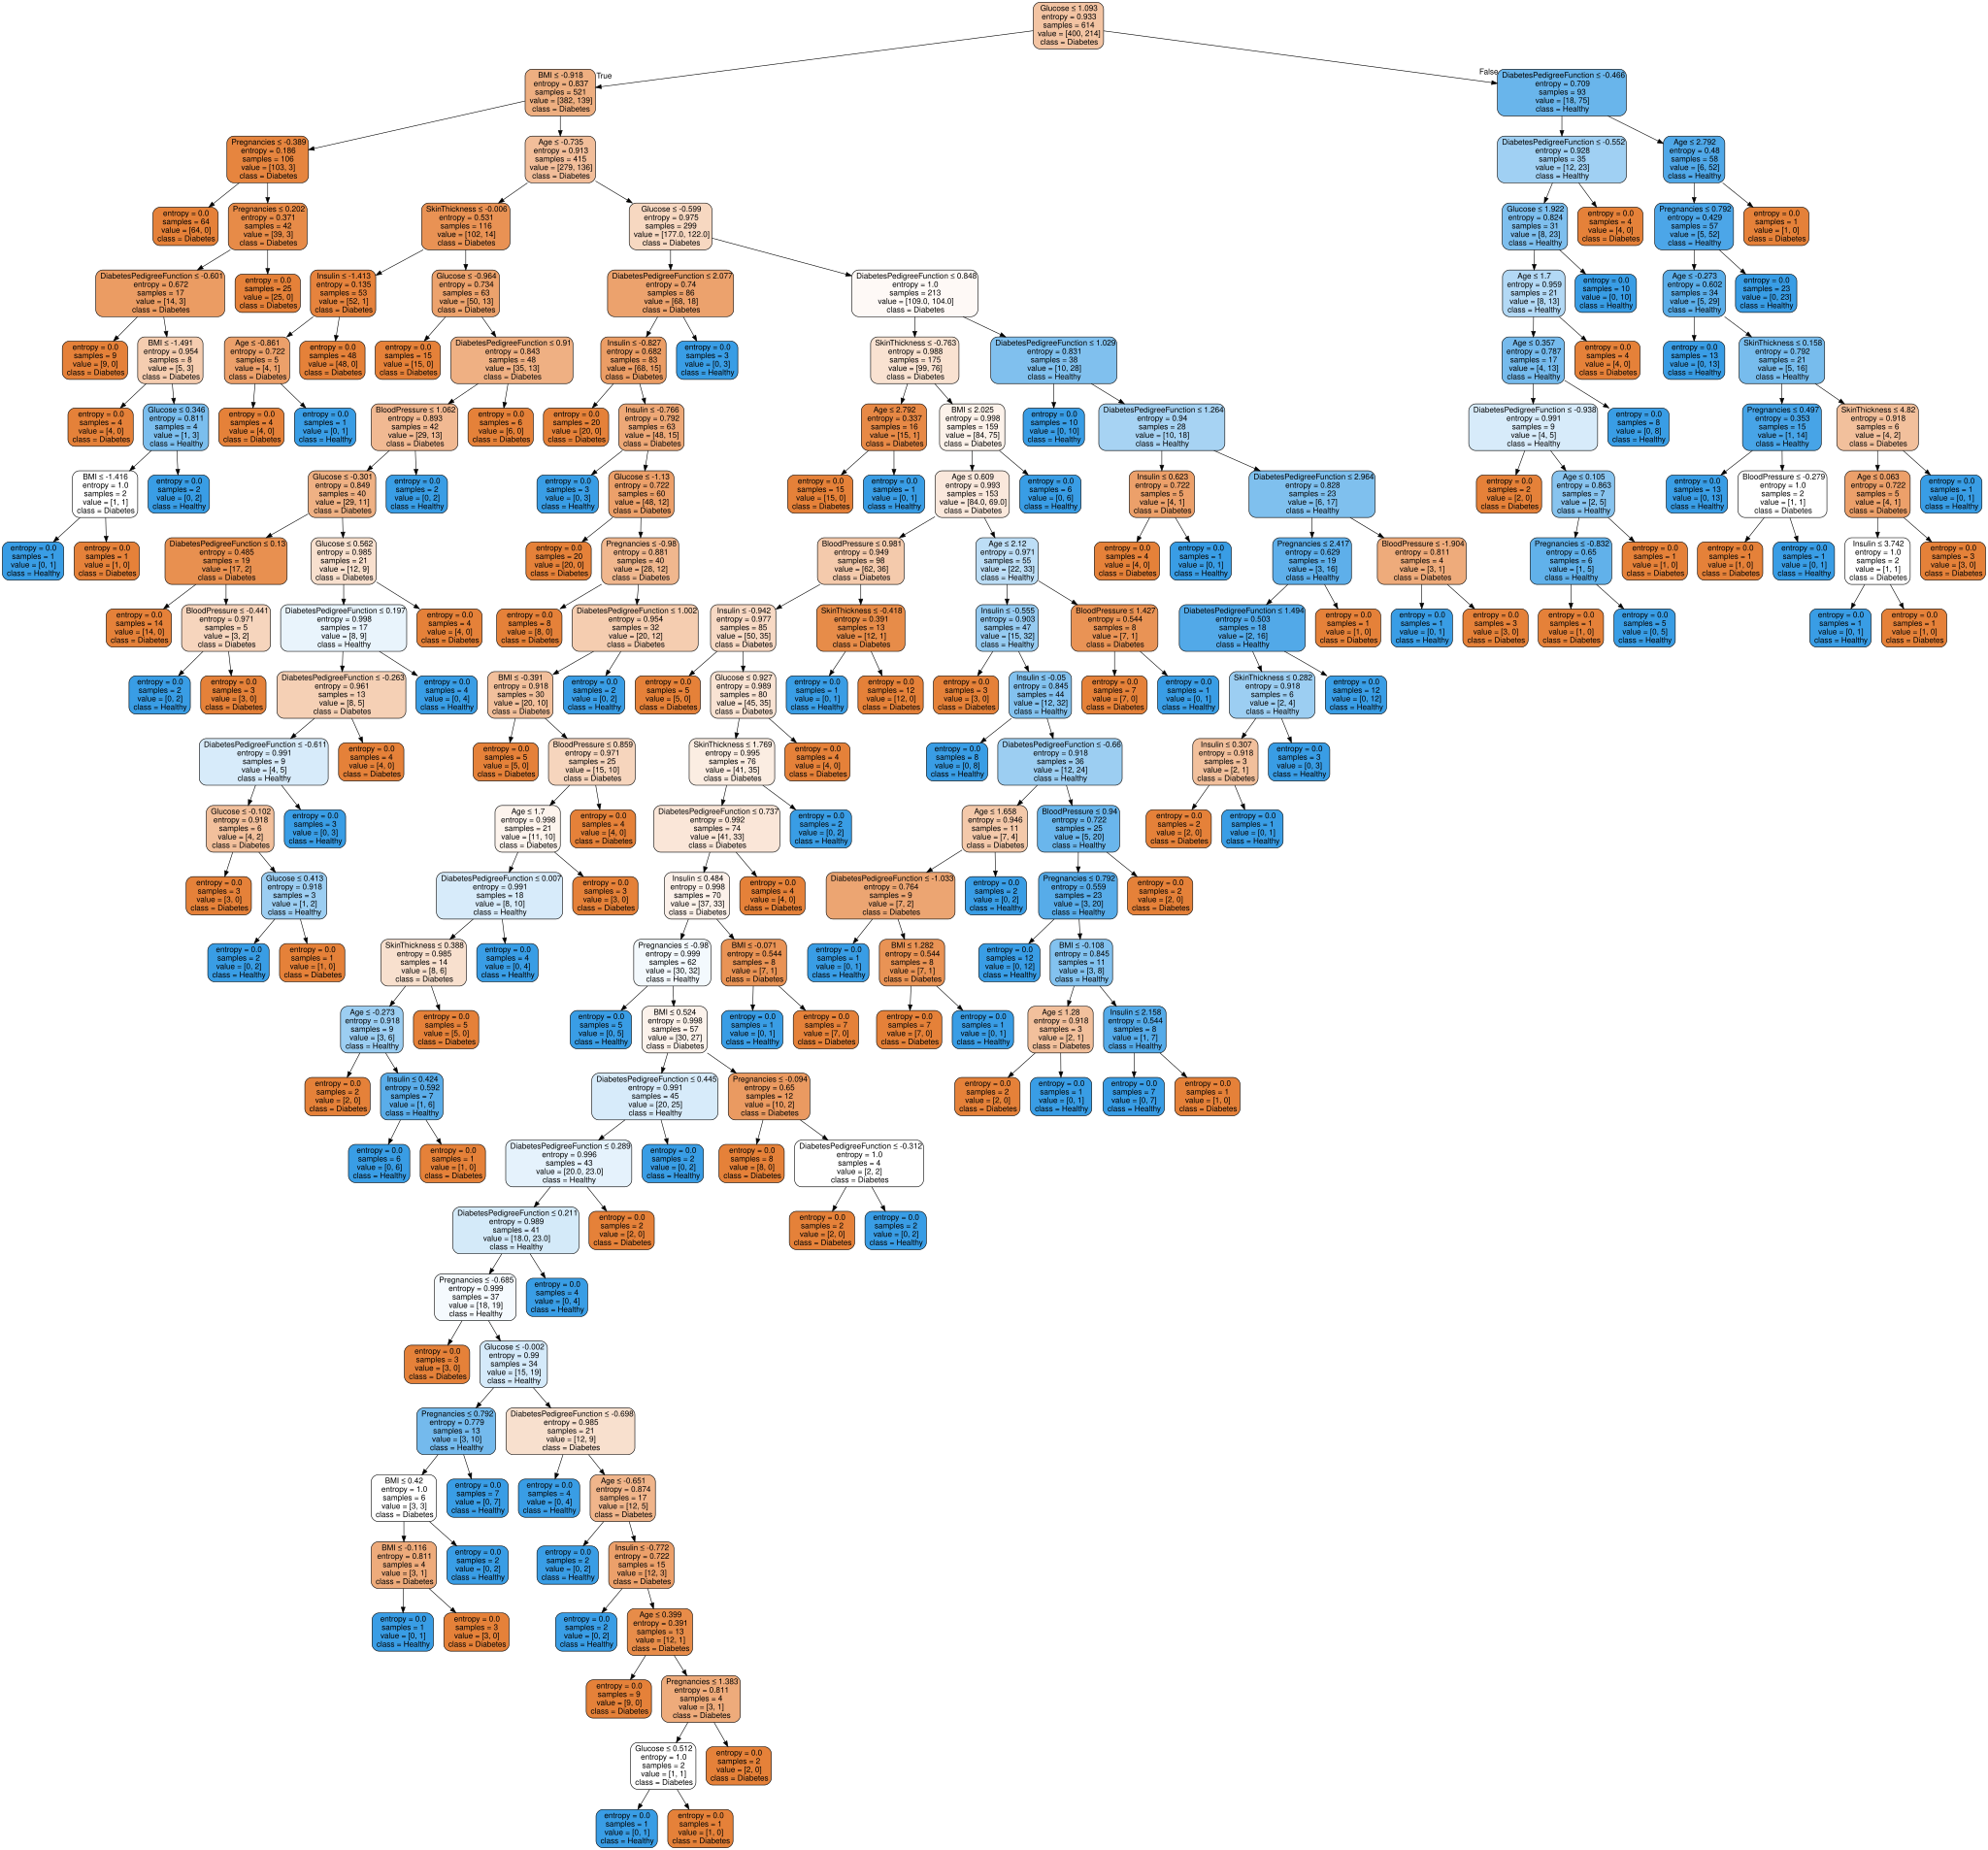

In [44]:
from sklearn import tree

import graphviz
from PIL import Image
dot_data = tree.export_graphviz(model_DT, out_file=None)
graph = graphviz.Source(dot_data)
graph.render("Titanic")

dot_data = tree.export_graphviz(model_DT, out_file=None,
                         feature_names=X.columns.values,
                         class_names=['Diabetes','Healthy'],
                         filled=True, rounded=True,
                         special_characters=True)

graph = graphviz.Source(dot_data)       # 새 graph 객체 생성
graph.render("Titanic", format="png")   # 파일 저장
graph                                    # Colab/Notebook에서 출력

In [45]:
y_pred = model_DT.predict(X_test)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1])

In [46]:
from sklearn import metrics

print('DecisionTreeClassifier: %.2f' % (metrics.accuracy_score(y_test, y_pred) * 100))

DecisionTreeClassifier: 77.92


In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[82 18]
 [16 38]]


In [48]:
from sklearn.metrics import classification_report

# 리포트 생성
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83       100
           1       0.68      0.70      0.69        54

    accuracy                           0.78       154
   macro avg       0.76      0.76      0.76       154
weighted avg       0.78      0.78      0.78       154



In [49]:
feature_importances = model_DT.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("All Feature Importances from RandomForestClassifier (sorted):")
print(importance_df)

All Feature Importances from RandomForestClassifier (sorted):
                    Feature  Importance
1                   Glucose    0.223459
6  DiabetesPedigreeFunction    0.183481
7                       Age    0.153995
5                       BMI    0.131507
4                   Insulin    0.098353
0               Pregnancies    0.084070
3             SkinThickness    0.070479
2             BloodPressure    0.054656
